In [81]:
%load_ext autoreload
%autoreload 2
from dig4bio.read_data import read_raman_file
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
models = ['anton532','anton785','kaiser','metrohm','mettler','tec','timegate','tornado']

raw_by_model =  {model: read_raman_file(file_name=model,level='raw') for model in models}

In [ ]:
def get_wavenumbers(df:pd.DataFrame):
    cols_to_numeric = pd.to_numeric(pd.Series(np.array(df.columns)),errors='coerce')
    return cols_to_numeric[cols_to_numeric.notna()].to_numpy()

summary_stats={}

for model,df in raw_by_model.items():

    numeric_cols = pd.to_numeric(df.columns, errors="coerce") # type: ignore
    spectral_cols = df.columns[numeric_cols.notna()]
    wavenumbers = numeric_cols[numeric_cols.notna()].astype(float)

    summary_stats[model] = {
            'wavenumbers': wavenumbers,
            'min_wavenumber': wavenumbers.min(),
            'max_wavenumber': wavenumbers.max(),
            'wavenumber_counts': len(wavenumbers)
            }

In [ ]:
print('** Wavenumber Ranges **')
name_width = max(len(model) for model in summary_stats)
for model,stats in summary_stats.items():
    print(f'{model:<{name_width}}: {stats['min_wavenumber']:>8.2f} - {stats['max_wavenumber']:>7.2f}')

** Wavenumber Ranges **
anton532:   200.00 - 3500.00
anton785:   100.00 - 2300.00
kaiser  :   -36.30 - 1941.30
metrohm :   202.22 - 3349.39
mettler :   300.00 - 3200.00
tec     :    85.00 - 3210.00
timegate:   200.93 - 1997.69
tornado :   300.00 - 3300.00


In [113]:
print('** Wavenumber Ranges **')
name_width = max(len(model) for model in summary_stats)
for model,stats in summary_stats.items():
    print(f'{model:<{name_width}}: {len(stats['wavenumbers']):>7.2f}')

** Wavenumber Ranges **
anton532: 1651.00
anton785: 1101.00
kaiser  : 6593.00
metrohm : 1917.00
mettler : 2901.00
tec     : 3126.00
timegate:  511.00
tornado : 3001.00


ValueError: Input could not be cast to an at-least-1D NumPy array

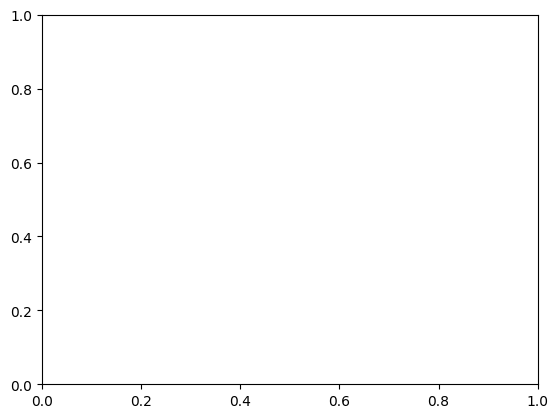

In [82]:
wavenumbers_to_plot = [dfs[model]['wavenumbers'] for model in files]

plt.plot(wavenumbers_to_plot)

In [ ]:
stats=[]
for file,df in dfs.items():
    stats.append({
        'Device': file,
        'Shape': df.shape,
        'Min': df.columns
        'Memory Usage (Mb)': round(df.memory_usage().sum()*10**-6,2)
    })

**** anton532 ****
Shape: (270, 1656)
Memory Usage: 3.58 Mb
**** anton785 ****
Shape: (270, 1106)
Memory Usage: 2.39 Mb
**** kaiser ****
Shape: (134, 6598)
Memory Usage: 7.07 Mb
**** metrohm ****
Shape: (399, 1922)
Memory Usage: 6.14 Mb
**** mettler ****
Shape: (275, 2906)
Memory Usage: 6.39 Mb
**** tec ****
Shape: (395, 3131)
Memory Usage: 9.89 Mb
**** timegate ****
Shape: (133, 516)
Memory Usage: 0.55 Mb
**** tornado ****
Shape: (385, 3006)
Memory Usage: 9.26 Mb
